# RAG voi LangChain - Phien ban cai tien

**Module 12 | AIVN** -- Pipeline RAG day du: PDF -> Embedding -> ChromaDB -> LLM -> Gradio UI

---

## 1. Cai dat thu vien

In [ ]:
!pip install -q \
  "torch>=2.0.0" \
  "transformers>=4.40.0" \
  "accelerate>=0.30.0" \
  "huggingface-hub>=0.23.0" \
  "sentence-transformers>=2.7.0" \
  "langchain>=0.2.0" \
  "langchain-core>=0.2.0" \
  "langchain-community>=0.1.0" \
  "langchain-text-splitters>=0.2.0" \
  "chromadb>=0.5.0" \
  "langchain-chroma>=0.2.0" \
  "pypdf>=4.2.0" \
  "langserve[all]>=0.1.0" \
  "fastapi>=0.115.0" \
  "uvicorn>=0.30.0" \
  "gradio>=5.0.0" \
  "langchain-huggingface" \
  "wget"
print("Cai dat hoan tat!")


Cai dat hoan tat!


## 2. Khoi tao du an

In [ ]:
import os, sys, logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')
logger = logging.getLogger(__name__)

PROJECT_ROOT = '/content/rag_langchain'
os.makedirs(os.path.join(PROJECT_ROOT, 'data_source', 'generative_ai'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'src', 'base'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'src', 'rag'), exist_ok=True)

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
print('Cau truc du an da san sang')


Cau truc du an da san sang


In [ ]:
%%bash
touch /content/rag_langchain/src/__init__.py
touch /content/rag_langchain/src/base/__init__.py
touch /content/rag_langchain/src/rag/__init__.py
echo "Package files tao xong"

Package files tao xong


## 3. Tai du lieu PDF

In [ ]:
import os, wget

DATA_DIR = '/content/rag_langchain/data_source/generative_ai'
os.makedirs(DATA_DIR, exist_ok=True)

pdf_links = [
    {'title': 'Tai lieu moi cua ban', 'url': 'https://docs.google.com/uc?export=download&id=1g3SHVn3dYyZlhzn4h99s9nTdpmESklSb'}
]

downloaded, skipped, failed = 0, 0, 0
for pdf_info in pdf_links:
    save_path = os.path.join(DATA_DIR, pdf_info['title'] + '.pdf')
    if os.path.exists(save_path):
        logger.info('[SKIP] Da ton tai: ' + pdf_info['title'] + '.pdf')
        skipped += 1
    else:
        try:
            logger.info('[DOWNLOAD] Dang tai: ' + pdf_info['title'])
            wget.download(pdf_info['url'], out=save_path)
            downloaded += 1
        except Exception as e:
            logger.error('[FAIL] ' + pdf_info['title'] + ': ' + str(e))
            failed += 1

print('Ket qua: ' + str(downloaded) + ' tai moi | ' + str(skipped) + ' da co | ' + str(failed) + ' that bai')


Ket qua: 0 tai moi | 1 da co | 0 that bai


## 4. Mo hinh LLM

Dung  - mo hinh nho gon, ho tro tieng Viet, chay tren T4 GPU Colab mien phi.

In [ ]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from langchain_huggingface import HuggingFacePipeline
from langchain_core.globals import set_llm_cache
from langchain_community.cache import InMemoryCache

def get_hf_llm(
    model_name='Qwen/Qwen2.5-3B-Instruct',
    temperature=0.2,
    max_new_tokens=250,
    top_p=0.75,
    **kwargs
):
    """
    Toi uu toc do cho Colab T4:
    - float16: on dinh, khong can bitsandbytes
    - max_new_tokens=250: giam thoi gian sinh text
    - InMemoryCache: cau hoi giong nhau khong goi LLM lai
    """
    logger.info('Dang tai model: ' + model_name)

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model_pipeline = pipeline(
        'text-generation',
        model=model,
        tokenizer=tokenizer,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_p=top_p,
        repetition_penalty=1.1,
    )

    llm = HuggingFacePipeline(pipeline=model_pipeline, model_kwargs=kwargs)
    set_llm_cache(InMemoryCache())
    logger.info('LLM da san sang (float16)')
    return llm


## 5. Xu ly van ban tieng Viet

In [ ]:
import re, unicodedata
from typing import List

def clean_vietnamese_text(text: str) -> str:
    """
    Lam sach van ban tieng Viet tu PDF.
    Buoc 1: Normalize Unicode NFC - chuan hoa ky tu co dau tieng Viet
    Buoc 2: Loai bo control characters an (category 'C') tu PDF, giu lai newline/tab
    Buoc 3: Chuan hoa khoang trang thua
    Buoc 4: Gop nhieu dong trong thanh mot
    """
    # Buoc 1: NFC - quan trong voi tieng Viet
    text = unicodedata.normalize('NFC', text)

    # Buoc 2: Loai bo control chars, giu lai newline va tab
    KEEP_CHARS = {'\n', '\t'}
    text = ''.join(
        char for char in text
        if not unicodedata.category(char).startswith('C') or char in KEEP_CHARS
    )

    # Buoc 3: Chuan hoa khoang trang (spaces/tabs), giu nguyen newline
    text = re.sub(r'[ \t]+', ' ', text)

    # Buoc 4: Gop nhieu dong trong thanh mot dong
    text = re.sub(r'\n\s*\n', '\n', text)

    return text.strip()

# Kiem thu nhanh
test = 'Xin  chao\n\n\nViet   Nam'
print(f"Input:  '{test}'")
print(f"Output: '{clean_vietnamese_text(test)}'")


Input:  'Xin  chao


Viet   Nam'
Output: 'Xin chao
Viet Nam'


## 6. Document Loader va Text Splitter

Ly do chon tham so:
- : du ngu canh (~1 doan van), khong qua dai de embedding mat y
- : ~25% overlap, tranh mat thong tin o ranh gioi chunk

In [ ]:
import glob
from tqdm import tqdm
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

class SimpleLoader:
    """Load PDF tu file hoac thu muc, tu dong lam sach van ban tieng Viet."""

    def load_pdf(self, pdf_file: str) -> List:
        docs = PyPDFLoader(pdf_file, extract_images=True).load()
        for doc in docs:
            doc.page_content = clean_vietnamese_text(doc.page_content)
        # Loai bo trang trong
        docs = [d for d in docs if len(d.page_content.strip()) > 20]
        return docs

    def load_dir(self, dir_path: str) -> List:
        """Load tat ca PDF trong thu muc, log ro file nao loi."""
        pdf_files = glob.glob(f"{dir_path}/*.pdf")
        if not pdf_files:
            raise ValueError(f"Khong tim thay file PDF trong: {dir_path}")

        all_docs, failed_files = [], []
        for pdf_file in tqdm(pdf_files, desc="Loading PDFs"):
            try:
                loaded = self.load_pdf(pdf_file)
                all_docs.extend(loaded)
                logger.info(f"[OK] {os.path.basename(pdf_file)}: {len(loaded)} trang")
            except Exception as e:
                logger.error(f"[FAIL] {os.path.basename(pdf_file)}: {e}")
                failed_files.append(pdf_file)

        if failed_files:
            print(f"CANH BAO: {len(failed_files)} file loi: {[os.path.basename(f) for f in failed_files]}")
        print(f"Loaded {len(all_docs)} trang tu {len(pdf_files) - len(failed_files)} file")
        return all_docs


class TextSplitter:
    """
    Chia tai lieu thanh cac chunk nho de embedding.
    - chunk_size=400 : du ngu canh (~1 doan van), khong qua dai
    - chunk_overlap=100: ~25% overlap, tranh mat thong tin o ranh gioi chunk
    - separators uu tien: paragraph -> line -> word -> char
    """
    def __init__(self, chunk_size: int = 400, chunk_overlap: int = 100):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        # Dinh nghia separators rieng de tranh loi escape trong notebook
        sep_paragraph = '\n\n'
        sep_line = '\n'
        sep_word = ' '
        sep_char = ''
        self.splitter = RecursiveCharacterTextSplitter(
            separators=[sep_paragraph, sep_line, sep_word, sep_char],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
        )

    def split(self, documents) -> List:
        chunks = self.splitter.split_documents(documents)
        # Loai bo chunk qua ngan (thuong la header/footer PDF)
        chunks = [c for c in chunks if len(c.page_content.strip()) > 50]
        logger.info(f"Chia thanh {len(chunks)} chunks (size={self.chunk_size}, overlap={self.chunk_overlap})")
        return chunks


## 7. Vector Database (ChromaDB)

**CAI TIEN Embedding model:** Dung  thay vi MiniLM.
- Cung da ngon ngu nhung vector 768 chieu (vs 384 cua MiniLM)
- Chat luong retrieval tot hon ro rang cho tieng Viet
- Trade-off: cham hon khoang 2 lan, nhung xung dang

**CAI TIEN Search strategy:** Dung MMR (Maximal Marginal Relevance) thay vi similarity thuan.
MMR can bang giua relevance va diversity, tranh tra ve cac chunk qua giong nhau.

In [ ]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

class VectorDB:
    # CAI TIEN: nang tu MiniLM len mpnet cho chat luong tot hon
    DEFAULT_EMBEDDING = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

    def __init__(
        self,
        documents=None,
        embedding_model: str = DEFAULT_EMBEDDING,
        collection_name: str = "vietnamese_docs",
        persist_dir: str = "/content/chroma_data",
    ):
        self.persist_dir = persist_dir
        self.collection_name = collection_name

        logger.info(f"Dang tai embedding model: {embedding_model}")
        self.embedding = HuggingFaceEmbeddings(
            model_name=embedding_model,
            model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"},
            encode_kwargs={"normalize_embeddings": True},  # Cosine similarity tot hon
        )
        self.db = self._build_db(documents)

    def _build_db(self, documents):
        if documents is None or len(documents) == 0:
            logger.info("Load ChromaDB tu disk (khong co documents moi)")
            db = Chroma(
                collection_name=self.collection_name,
                embedding_function=self.embedding,
                persist_directory=self.persist_dir,
            )
        else:
            logger.info(f"Tao ChromaDB moi voi {len(documents)} chunks...")
            db = Chroma.from_documents(
                documents=documents,
                embedding=self.embedding,
                collection_name=self.collection_name,
                persist_directory=self.persist_dir,
            )
            logger.info(f"Da index {db._collection.count()} vectors")
        return db

    def get_retriever(self, search_kwargs: dict = None, search_type: str = "mmr"):
        """
        CAI TIEN: Dung MMR (Maximal Marginal Relevance) thay vi similarity thuan.
        MMR can bang giua relevance va diversity:
        - fetch_k: so ung vien MMR xem xet (nen > k)
        - k: so chunk cuoi cung tra ve
        """
        if search_kwargs is None:
            search_kwargs = {"k": 4, "fetch_k": 20}
        return self.db.as_retriever(search_type=search_type, search_kwargs=search_kwargs)

    def collection_info(self):
        count = self.db._collection.count()
        print(f"Collection '{self.collection_name}': {count} vectors")
        return count

## 8. RAG Chain va Output Parser

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

class FocusedAnswerParser(StrOutputParser):
    """
    Parser trich xuat cau tra loi tu output cua LLM.
    Dung regex split cau thay vi split('.') de tranh loi voi so thap phan.
    """
    def parse(self, text: str) -> str:
        text = text.strip()

        # Trich xuat phan sau [TRA LOI]:
        marker = '[TRA LOI]:'
        if marker in text:
            answer = text.split(marker)[-1].strip()
        else:
            answer = text

        # Loai bo bullet points
        newline = '\n'
        answer = re.sub(r'^\s*[\u2022\-\*]\s*', '', answer, flags=re.MULTILINE)

        # Chuan hoa newlines thanh space
        answer = answer.replace(newline, ' ').strip()
        answer = re.sub(r'\s+', ' ', answer)

        # Split cau bang regex, tranh loi voi so thap phan
        pattern = r'(?<=[.!?])\s+(?=[A-Z\u00C0-\u024F\u1EA0-\u1EF9])'
        sentences = re.split(pattern, answer)
        sentences = [s.strip() for s in sentences if s.strip() and len(s.strip()) > 10]

        result = ' '.join(sentences[:5])
        if result and not result[-1] in '.!?':
            result += '.'
        return result if result else 'Khong tim thay thong tin lien quan trong tai lieu.'


class OfflineRAG:
    """
    Pipeline RAG hoan chinh: Retrieval -> Augmentation -> Generation.
    Prompt duoc thiet ke de:
    1. Gioi han cau tra loi trong tai lieu (tranh hallucination)
    2. Yeu cau 3-5 cau chi tiet
    3. Xu ly truong hop khong co thong tin
    4. Them so trang nguon trich dan vao context
    """

    PROMPT_TEMPLATE = (
        'Ban la tro ly AI chuyen phan tich tai lieu tieng Viet.'
        ' Nhiem vu cua ban la tra loi cau hoi DUA TREN TAI LIEU duoc cung cap.'
        '\n\n'
        '[TAI LIEU THAM KHAO]:\n{context}\n\n'
        '[CAU HOI]:\n{question}\n\n'
        'Quy tac tra loi:\n'
        '- Chi dung thong tin tu tai lieu tren, khong them kien thuc ben ngoai\n'
        '- Neu tai lieu khong de cap, hay noi: "Tai lieu khong co thong tin ve van de nay"\n'
        '- Tra loi bang 3-5 cau day du, ro rang, bang tieng Viet\n'
        '- Khong lap lai cau hoi trong cau tra loi\n\n'
        '[TRA LOI]:'
    )

    def __init__(self, llm):
        self.llm = llm
        self.prompt = PromptTemplate.from_template(self.PROMPT_TEMPLATE)
        self.answer_parser = FocusedAnswerParser()

    def get_chain(self, retriever):
        def format_docs(docs):
            """Them so trang nguon vao context de tang minh bach."""
            formatted, seen = [], set()
            for i, doc in enumerate(docs, 1):
                content = doc.page_content.strip()
                if content and len(content) > 40 and content not in seen:
                    page = doc.metadata.get('page', '?')
                    sep = '\n'
                    formatted.append(f'[Doan {i} - Trang {page}]:{sep}{content}')
                    seen.add(content)
            sep2 = '\n\n'
            return sep2.join(formatted)

        rag_chain = (
            {'context': retriever | format_docs, 'question': RunnablePassthrough()}
            | self.prompt
            | self.llm
            | self.answer_parser
        )
        return rag_chain


## 9. Khoi chay Pipeline RAG

In [ ]:
os.chdir('/content/rag_langchain')

print('Buoc 1/5: Khoi tao LLM...')
llm = get_hf_llm()

print('Buoc 2/5: Load tai lieu PDF...')
data_dir = '/content/rag_langchain/data_source/generative_ai'
loader = SimpleLoader()
raw_docs = loader.load_dir(data_dir)
print('   ' + str(len(raw_docs)) + ' trang duoc load')

print('Buoc 3/5: Chia van ban thanh chunks...')
text_splitter = TextSplitter(chunk_size=400, chunk_overlap=100)
split_docs = text_splitter.split(raw_docs)
print('   ' + str(len(split_docs)) + ' chunks')

print('Buoc 4/5: Tao Vector Database...')
vdb = VectorDB(documents=split_docs)
vdb.collection_info()
retriever = vdb.get_retriever(search_type='mmr', search_kwargs={'k': 3, 'fetch_k': 10})

print('Buoc 5/5: Khoi tao RAG chain...')
rag = OfflineRAG(llm)
rag_chain = rag.get_chain(retriever)

def answer_question(question):
    if not question or not question.strip():
        return 'Vui long nhap cau hoi.'
    try:
        return rag_chain.invoke(question.strip())
    except Exception as e:
        logger.error('Loi khi tra loi: ' + str(e))
        return 'Da xay ra loi: ' + str(e)

print('Pipeline RAG da san sang!')


Buoc 1/5: Khoi tao LLM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'top_p', 'pad_token_id', 'max_new_tokens', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Buoc 2/5: Load tai lieu PDF...


Loading PDFs: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]


Loaded 17 trang tu 1 file
   17 trang duoc load
Buoc 3/5: Chia van ban thanh chunks...
   179 chunks
Buoc 4/5: Tao Vector Database...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Collection 'vietnamese_docs': 716 vectors
Buoc 5/5: Khoi tao RAG chain...
Pipeline RAG da san sang!


## 10. Kiem thu Pipeline (Evaluation)

Chay cac cau hoi mau de xac nhan pipeline hoat dong dung truoc khi deploy UI.

Dang danh gia pipeline...
--------------------------------------------------
Cau 1: Tai lieu nay noi ve chu de gi?...


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Latency: 0.14s | Chunks: 3 | Score: 5/5
Cau 2: Cac khai niem chinh duoc de cap trong tai lieu la ...


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Latency: 608.04s | Chunks: 3 | Score: 5/5
Cau 3: Hay tom tat noi dung chinh cua tai lieu....
   Latency: 560.45s | Chunks: 3 | Score: 5/5
Cau 4: Co nhung phuong phap nao duoc gioi thieu?...


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Latency: 552.7s | Chunks: 3 | Score: 5/5
Cau 5: Ket luan cua tai lieu la gi?...
   Latency: 557.86s | Chunks: 3 | Score: 5/5
--------------------------------------------------
Danh gia xong!


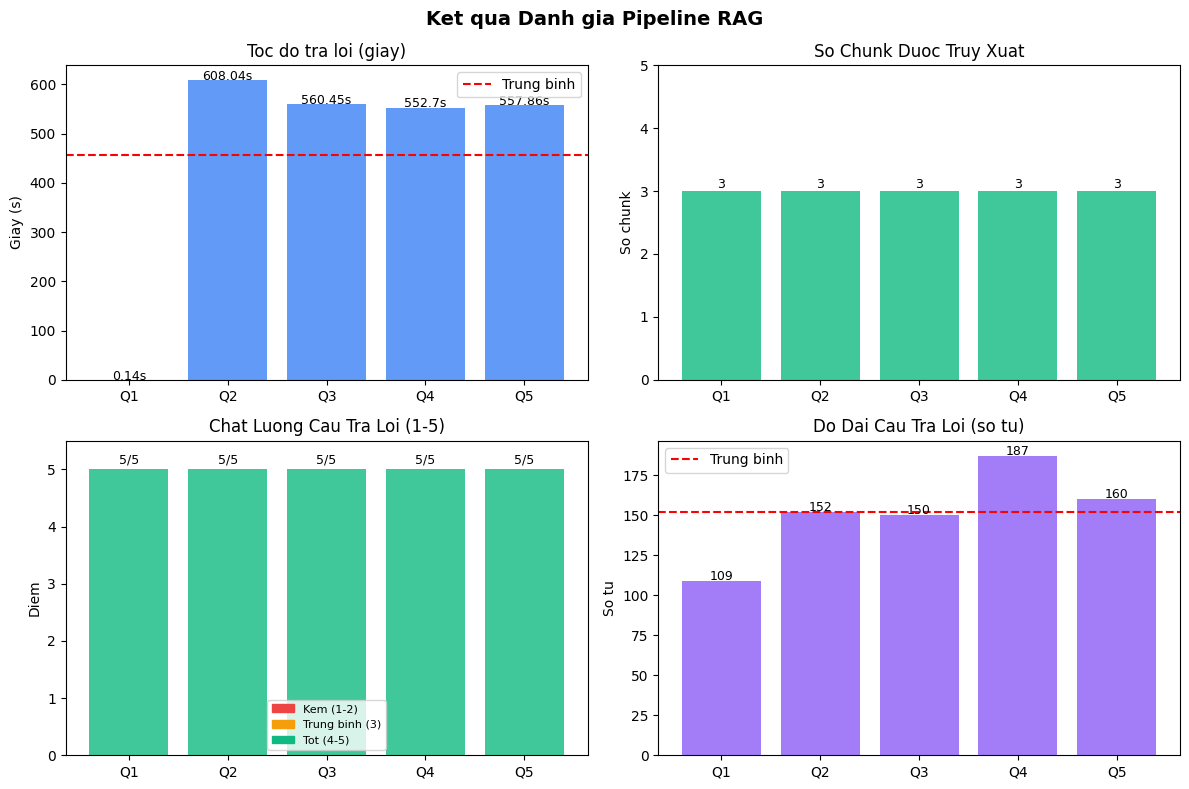


=== TOM TAT DANH GIA ===
Latency trung binh : 455.84s
Latency nhanh nhat : 0.14s
Latency cham nhat  : 608.04s
Diem chat luong TB : 5.0/5
Do dai tra loi TB  : 151.6 tu
Bieu do luu tai    : /content/rag_evaluation.png


In [ ]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Danh sach cau hoi kiem thu ──
TEST_QUESTIONS = [
    'Tai lieu nay noi ve chu de gi?',
    'Cac khai niem chinh duoc de cap trong tai lieu la gi?',
    'Hay tom tat noi dung chinh cua tai lieu.',
    'Co nhung phuong phap nao duoc gioi thieu?',
    'Ket luan cua tai lieu la gi?',
]

def score_answer(answer):
    """Cham diem tu dong don gian dua tren do dai va chat luong cau tra loi."""
    if not answer or len(answer) < 20:
        return 1
    if 'Khong tim thay' in answer or 'khong co thong tin' in answer.lower():
        return 2
    words = len(answer.split())
    sentences = answer.count('.') + answer.count('!') + answer.count('?')
    if words >= 50 and sentences >= 3:
        return 5
    elif words >= 30 and sentences >= 2:
        return 4
    elif words >= 15:
        return 3
    return 2

# ── Chay danh gia ──
results = []
print('Dang danh gia pipeline...')
print('-' * 50)

for i, q in enumerate(TEST_QUESTIONS, 1):
    print('Cau ' + str(i) + ': ' + q[:50] + '...')

    # Do latency
    t0 = time.time()
    answer = answer_question(q)
    latency = round(time.time() - t0, 2)

    # Do so chunk retrieved
    retrieved_docs = retriever.invoke(q)
    num_chunks = len(retrieved_docs)

    # Do chat luong
    score = score_answer(answer)

    results.append({
        'question': 'Q' + str(i),
        'latency': latency,
        'chunks': num_chunks,
        'score': score,
        'answer_len': len(answer.split()),
    })
    print('   Latency: ' + str(latency) + 's | Chunks: ' + str(num_chunks) + ' | Score: ' + str(score) + '/5')

print('-' * 50)
print('Danh gia xong!')

# ── Ve bieu do ──
labels   = [r['question'] for r in results]
latencies = [r['latency']  for r in results]
chunks   = [r['chunks']   for r in results]
scores   = [r['score']    for r in results]
ans_lens = [r['answer_len'] for r in results]
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Ket qua Danh gia Pipeline RAG', fontsize=14, fontweight='bold')

# Bieu do 1: Latency
ax1 = axes[0, 0]
bars1 = ax1.bar(x, latencies, color='#3b82f6', alpha=0.8)
ax1.axhline(np.mean(latencies), color='red', linestyle='--', linewidth=1.5, label='Trung binh')
ax1.set_title('Toc do tra loi (giay)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Giay (s)')
ax1.legend()
for bar, v in zip(bars1, latencies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(v) + 's', ha='center', fontsize=9)

# Bieu do 2: So chunk retrieved
ax2 = axes[0, 1]
bars2 = ax2.bar(x, chunks, color='#10b981', alpha=0.8)
ax2.set_title('So Chunk Duoc Truy Xuat')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('So chunk')
ax2.set_ylim(0, max(chunks) + 2)
for bar, v in zip(bars2, chunks):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(v), ha='center', fontsize=9)

# Bieu do 3: Chat luong cau tra loi
ax3 = axes[1, 0]
colors = ['#ef4444' if s <= 2 else '#f59e0b' if s == 3 else '#10b981' for s in scores]
bars3 = ax3.bar(x, scores, color=colors, alpha=0.8)
ax3.set_title('Chat Luong Cau Tra Loi (1-5)')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylabel('Diem')
ax3.set_ylim(0, 5.5)
red_p = mpatches.Patch(color='#ef4444', label='Kem (1-2)')
yel_p = mpatches.Patch(color='#f59e0b', label='Trung binh (3)')
grn_p = mpatches.Patch(color='#10b981', label='Tot (4-5)')
ax3.legend(handles=[red_p, yel_p, grn_p], fontsize=8)
for bar, v in zip(bars3, scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(v) + '/5', ha='center', fontsize=9)

# Bieu do 4: Do dai cau tra loi
ax4 = axes[1, 1]
bars4 = ax4.bar(x, ans_lens, color='#8b5cf6', alpha=0.8)
ax4.axhline(np.mean(ans_lens), color='red', linestyle='--', linewidth=1.5, label='Trung binh')
ax4.set_title('Do Dai Cau Tra Loi (so tu)')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_ylabel('So tu')
ax4.legend()
for bar, v in zip(bars4, ans_lens):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/rag_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tom tat ──
print('')
print('=== TOM TAT DANH GIA ===')
print('Latency trung binh : ' + str(round(np.mean(latencies), 2)) + 's')
print('Latency nhanh nhat : ' + str(min(latencies)) + 's')
print('Latency cham nhat  : ' + str(max(latencies)) + 's')
print('Diem chat luong TB : ' + str(round(np.mean(scores), 2)) + '/5')
print('Do dai tra loi TB  : ' + str(round(np.mean(ans_lens), 1)) + ' tu')
print('Bieu do luu tai    : /content/rag_evaluation.png')


## 11. Giao dien Gradio

CAI TIEN UI:
- Them lich su hoi thoai (Chatbot component)
- Nut xoa lich su
- Enter de gui (khong phai chi click nut)
- Cau hoi mau de nguoi dung thu nhanh

In [ ]:
import gradio as gr
from datetime import datetime

custom_css = (
    '#question-area textarea { font-size: 16px; line-height: 1.6; }'
    '#answer-area textarea { font-size: 15px; line-height: 1.7; background: #f8f9fa; }'
    'footer { display: none !important; }'
)

def answer_with_history(question, history):
    if not question or not question.strip():
        return history, '', 'Vui long nhap cau hoi.'
    history = history or []
    answer = answer_question(question.strip())
    timestamp = datetime.now().strftime('%H:%M')
    history.append(('[' + timestamp + '] ' + question, answer))
    return history, '', answer

with gr.Blocks(title='RAG Vietnamese QA', css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.Markdown('# RAG - Hoi Dap Tai Lieu Tieng Viet')
    gr.Markdown('He thong tra loi cau hoi dua tren tai lieu PDF, su dung LangChain + ChromaDB + Qwen2.5')

    with gr.Row():
        with gr.Column(scale=1):
            question_input = gr.Textbox(
                label='Cau hoi cua ban',
                placeholder='Vi du: Tai lieu nay noi ve chu de gi?',
                lines=4,
                elem_id='question-area'
            )
            with gr.Row():
                submit_btn = gr.Button('Tim cau tra loi', variant='primary', scale=2)
                clear_btn = gr.Button('Xoa', scale=1)

            gr.Examples(
                examples=[
                    ['Tai lieu nay noi ve chu de gi?'],
                    ['Hay tom tat noi dung chinh.'],
                    ['Cac khai niem quan trong la gi?'],
                ],
                inputs=question_input,
                label='Cau hoi mau'
            )

        with gr.Column(scale=2):
            answer_output = gr.Textbox(
                label='Cau tra loi',
                lines=5,
                interactive=False,
                elem_id='answer-area'
            )
            chatbot = gr.Chatbot(label='Lich su hoi thoai', height=300)

    submit_btn.click(
        fn=answer_with_history,
        inputs=[question_input, chatbot],
        outputs=[chatbot, question_input, answer_output],
    )
    question_input.submit(
        fn=answer_with_history,
        inputs=[question_input, chatbot],
        outputs=[chatbot, question_input, answer_output],
    )
    clear_btn.click(
        fn=lambda: ([], '', ''),
        outputs=[chatbot, question_input, answer_output]
    )

demo.launch(share=True)


/tmp/ipykernel_23799/2444965526.py:19: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='RAG Vietnamese QA', css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_23799/2444965526.py:19: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title='RAG Vietnamese QA', css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_23799/2444965526.py:53: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(label='Lich su hoi thoai', height=300)
/tmp/ipykernel_23799

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ce2314a66cb365304.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
